# Conversation Clustering on SageMaker

Runs end-to-end inside a SageMaker notebook (Studio or classic Notebook instance).

| Stage | Service | Notes |
|---|---|---|
| Data | **S3** | Raw CSV lives in a bucket; nothing stored on the notebook volume |
| Embeddings | **Bedrock Titan Text Embeddings v2** | 1024-d, multilingual, parallel calls |
| Clustering | **SageMaker built-in KMeans** | Managed training job on a CPU instance; not the notebook kernel |
| Cluster labels | **Bedrock Claude 3.5 Haiku** | Semantic labels from representative convs |
| Outputs | **S3** | Clustered convs, user segments, labels, embeddings |

**Prereqs (runs once on the notebook instance)**
- Instance role has: `AmazonSageMakerFullAccess`, `AmazonBedrockFullAccess` (or scoped-down invoke permission for the two models), and R/W on the S3 bucket below.
- Bedrock model access granted in the console for `amazon.titan-embed-text-v2:0` and `anthropic.claude-3-5-haiku-20241022-v1:0` in the region you're running in.
- A kernel with `boto3`, `sagemaker`, `scikit-learn`, `pandas`, `tenacity`, `tqdm`, `matplotlib` (SageMaker's built-in `conda_python3` / `Data Science` kernels already have most of them).

In [ ]:
# One-time install for anything the kernel is missing.
%pip install -q boto3 sagemaker tenacity tqdm

## 1. Environment & config

On SageMaker we pull the execution role and default bucket from the session instead of hard-coding them.

In [28]:
"""
AWS-powered conversation clustering pipeline for Hey Banco.

Replaces the local `sentence-transformers` + regex-labeling pipeline with:
  1. Amazon Bedrock Titan Text Embeddings v2   → multilingual embeddings
  2. scikit-learn KMeans (or SageMaker KMeans) → clustering
  3. Amazon Bedrock Claude                      → semantic cluster labels

Why this is faster/better than the local version:
  - Titan v2 is served, concurrent, and produces 1024-dim embeddings tuned
    for retrieval/clustering across 100+ languages (including Spanish).
  - Claude labels clusters from the actual text, so labels stay meaningful
    even when new topics (that don't match the hard-coded regexes) appear.
  - Everything is I/O bound on the API, so ThreadPoolExecutor gives a large
    speedup without needing a GPU locally.

Prereqs:
    pip install boto3 tenacity scikit-learn pandas numpy tqdm
    aws configure   # or set AWS_PROFILE / AWS_REGION
    # Enable model access in the Bedrock console for:
    #   - amazon.titan-embed-text-v2:0
    #   - anthropic.claude-3-5-haiku-20241022-v1:0  (cheap + fast for labels)
"""

from __future__ import annotations

import json
import logging
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass
from typing import Iterable, Sequence

import boto3
import numpy as np
import pandas as pd
from botocore.config import Config
from tenacity import (
    retry,
    retry_if_exception_type,
    stop_after_attempt,
    wait_exponential,
)
from tqdm.auto import tqdm

log = logging.getLogger(__name__)

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------

TITAN_EMBED_MODEL_ID = "amazon.titan-embed-text-v2:0"
TITAN_EMBED_DIM = 1024  # v2 supports 256 / 512 / 1024; 1024 is the default
# Claude 3.5 Haiku is marked Legacy on Bedrock as of 2026; Haiku 4.5 is the
# current active Haiku-tier model. Same Messages API, drop-in swap.
CLAUDE_MODEL_ID = "anthropic.claude-haiku-4-5-20251001-v1:0"


def _resolve_claude_invocation_id(region: str) -> str:
    """Anthropic Claude 3.5+ models on Bedrock require cross-region inference
    profiles — the bare `anthropic.claude-...` ID can't be invoked on-demand.
    The profile ID is the bare model ID prefixed with the geo code derived
    from the current AWS region.

    Docs: https://docs.aws.amazon.com/bedrock/latest/userguide/cross-region-inference.html
    """
    prefix_map = {
        "us": "us.",
        "eu": "eu.",
        "ap": "au.",   # Asia-Pacific uses the `au.` geo profile on Bedrock
        "ca": "us.",   # Canada routes to US profile
        "sa": "us.",   # South America routes to US profile
    }
    geo = region.split("-", 1)[0].lower()
    return prefix_map.get(geo, "us.") + CLAUDE_MODEL_ID

# Titan v2 hard limit is 8192 tokens; ~4 chars/token keeps us safely under.
MAX_CHARS_PER_DOC = 20_000


@dataclass
class BedrockClients:
    """Thin wrapper so we can reuse the same session across calls."""

    runtime: "boto3.client"
    region: str = "us-east-1"

    @classmethod
    def build(cls, region: str | None = None) -> "BedrockClients":
        # On SageMaker, AWS_REGION / AWS_DEFAULT_REGION are already set by
        # the notebook instance; fall back to the session's region, then us-east-1.
        if region is None:
            region = (
                os.getenv("AWS_REGION")
                or os.getenv("AWS_DEFAULT_REGION")
                or boto3.session.Session().region_name
                or "us-east-1"
            )
        cfg = Config(
            region_name=region,
            retries={"max_attempts": 8, "mode": "adaptive"},
            read_timeout=60,
            connect_timeout=10,
        )
        return cls(runtime=boto3.client("bedrock-runtime", config=cfg), region=region)


# ---------------------------------------------------------------------------
# 1. Embeddings via Bedrock Titan v2
# ---------------------------------------------------------------------------


class _ThrottlingError(Exception):
    """Internal marker so tenacity retries only on throttling / 5xx."""


@retry(
    retry=retry_if_exception_type(_ThrottlingError),
    stop=stop_after_attempt(6),
    wait=wait_exponential(multiplier=1, min=1, max=30),
    reraise=True,
)
def _embed_one(
    clients: BedrockClients,
    text: str,
    dimensions: int = TITAN_EMBED_DIM,
) -> np.ndarray:
    body = json.dumps(
        {
            "inputText": text[:MAX_CHARS_PER_DOC],
            "dimensions": dimensions,
            "normalize": True,  # unit-norm → cosine == dot product
        }
    )
    try:
        resp = clients.runtime.invoke_model(
            modelId=TITAN_EMBED_MODEL_ID,
            body=body,
            contentType="application/json",
            accept="application/json",
        )
    except clients.runtime.exceptions.ThrottlingException as e:
        raise _ThrottlingError(str(e)) from e
    except Exception as e:
        # Bedrock surfaces 5xx as ModelError / InternalServerException
        msg = str(e)
        if any(tag in msg for tag in ("Throttl", "ServiceUnavailable", "InternalServer")):
            raise _ThrottlingError(msg) from e
        raise

    payload = json.loads(resp["body"].read())
    return np.asarray(payload["embedding"], dtype=np.float32)


def embed_documents(
    texts: Sequence[str],
    clients: BedrockClients | None = None,
    max_workers: int = 16,
    dimensions: int = TITAN_EMBED_DIM,
    show_progress: bool = True,
) -> np.ndarray:
    """Embed a list of documents in parallel.

    Titan's per-request latency is ~100-300 ms; 16 concurrent workers gives
    roughly a 10-15x speedup over serial calls without tripping default
    account throttling limits. Increase `max_workers` if you've requested
    a higher TPS quota for Bedrock.
    """
    clients = clients or BedrockClients.build()
    out = np.empty((len(texts), dimensions), dtype=np.float32)

    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = {
            pool.submit(_embed_one, clients, t, dimensions): i
            for i, t in enumerate(texts)
        }
        it = as_completed(futures)
        if show_progress:
            it = tqdm(it, total=len(futures), desc="Titan embeddings")
        for fut in it:
            idx = futures[fut]
            out[idx] = fut.result()

    return out


# ---------------------------------------------------------------------------
# 2. Cluster labeling via Bedrock Claude
# ---------------------------------------------------------------------------

_LABEL_SYSTEM_PROMPT = (
    "Eres un analista de soporte de un banco digital. Recibirás ejemplos de "
    "conversaciones de un mismo grupo (cluster). Devuelve SOLO un JSON con: "
    '{"label": "<3-6 palabras en español>", "intent": "<una frase corta>", '
    '"keywords": ["<5 palabras clave>"]}. '
    "No incluyas texto fuera del JSON."
)


@retry(
    retry=retry_if_exception_type(_ThrottlingError),
    stop=stop_after_attempt(5),
    wait=wait_exponential(multiplier=1, min=1, max=20),
    reraise=True,
)
def _label_one_cluster(
    clients: BedrockClients,
    cluster_id: int,
    samples: Sequence[str],
    max_sample_chars: int = 500,
) -> dict:
    # Keep prompt cheap: trim each sample and cap at ~10 samples.
    trimmed = [s[:max_sample_chars].replace("\n", " ") for s in samples[:10]]
    user_msg = (
        f"Cluster #{cluster_id}. Conversaciones representativas:\n\n"
        + "\n---\n".join(f"{i+1}. {t}" for i, t in enumerate(trimmed))
    )

    body = json.dumps(
        {
            "anthropic_version": "bedrock-2023-05-31",
            "max_tokens": 300,
            "temperature": 0.0,
            "system": _LABEL_SYSTEM_PROMPT,
            "messages": [{"role": "user", "content": user_msg}],
        }
    )
    try:
        resp = clients.runtime.invoke_model(
            modelId=_resolve_claude_invocation_id(clients.region),
            body=body,
            contentType="application/json",
            accept="application/json",
        )
    except Exception as e:
        msg = str(e)
        if any(tag in msg for tag in ("Throttl", "ServiceUnavailable", "InternalServer")):
            raise _ThrottlingError(msg) from e
        raise

    payload = json.loads(resp["body"].read())
    text = payload["content"][0]["text"].strip()

    # Strip possible ```json fences.
    if text.startswith("```"):
        text = text.strip("`")
        text = text.split("\n", 1)[1] if "\n" in text else text
        text = text.rsplit("```", 1)[0]

    try:
        parsed = json.loads(text)
    except json.JSONDecodeError:
        log.warning("Claude returned non-JSON for cluster %s: %r", cluster_id, text)
        parsed = {"label": "sin_etiqueta", "intent": text[:120], "keywords": []}

    parsed["cluster"] = cluster_id
    return parsed


def label_clusters(
    samples_per_cluster: dict[int, Sequence[str]],
    clients: BedrockClients | None = None,
    max_workers: int = 4,
) -> pd.DataFrame:
    """Generate a semantic label for each cluster using Claude."""
    clients = clients or BedrockClients.build()
    rows: list[dict] = []
    with ThreadPoolExecutor(max_workers=max_workers) as pool:
        futures = [
            pool.submit(_label_one_cluster, clients, cid, samples)
            for cid, samples in samples_per_cluster.items()
        ]
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Claude labels"):
            rows.append(fut.result())
    return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)


# ---------------------------------------------------------------------------
# 3. End-to-end helper
# ---------------------------------------------------------------------------


def build_conv_documents(chat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate raw interactions into one document per (conv_id, user_id)."""
    chat = chat.sort_values(["conv_id", "date"])
    return (
        chat.groupby(["conv_id", "user_id"])["input"]
        .apply(lambda msgs: " ".join(msgs.astype(str)))
        .reset_index()
        .rename(columns={"input": "texto_completo"})
    )


def pick_cluster_samples(
    conv_docs: pd.DataFrame,
    embeddings: np.ndarray,
    kmeans,
    n_samples: int = 8,
) -> dict[int, list[str]]:
    """Pick the `n_samples` conversations closest to each centroid."""
    distances = kmeans.transform(embeddings)  # (N, K)
    samples: dict[int, list[str]] = {}
    for c in range(kmeans.n_clusters):
        mask = conv_docs["cluster"].values == c
        if not mask.any():
            samples[c] = []
            continue
        d = distances[mask, c]
        top_idx = np.argsort(d)[:n_samples]
        samples[c] = conv_docs.loc[mask, "texto_completo"].iloc[top_idx].tolist()
    return samples


# ---------------------------------------------------------------------------
# 4. SageMaker helpers (S3 I/O + built-in KMeans)
# ---------------------------------------------------------------------------


def upload_embeddings_to_s3(
    embeddings: np.ndarray,
    bucket: str,
    key: str,
) -> str:
    """Upload a float32 numpy array to S3 as .npy. Returns the s3:// URI."""
    import io

    s3 = boto3.client("s3")
    buf = io.BytesIO()
    np.save(buf, embeddings.astype(np.float32))
    buf.seek(0)
    s3.upload_fileobj(buf, bucket, key)
    return f"s3://{bucket}/{key}"


def train_sagemaker_kmeans(
    embeddings: np.ndarray,
    k: int,
    role: str,
    bucket: str,
    prefix: str = "hey-banco/kmeans",
    instance_type: str = "ml.c5.2xlarge",
    instance_count: int = 1,
    feature_dim: int | None = None,
    mini_batch_size: int = 500,
    wait: bool = True,
):
    """Train SageMaker's built-in KMeans on the given embeddings.

    Uses the low-level boto3 ``create_training_job`` API directly. The
    higher-level ``sagemaker.KMeans`` estimator merges values from the
    SageMaker admin ``config.yaml``, which can inject a
    ``TrainingJob.Environment`` block that the built-in algorithm rejects.
    Going straight to boto3 bypasses that entire code path.

    Returns (training_job_info, cluster_centers) where:
      * training_job_info is the ``DescribeTrainingJob`` response (dict).
      * cluster_centers is a numpy array of shape (k, dim).
    """
    import io
    import time
    import uuid

    import sagemaker  # only used for image_uris.retrieve

    # ---- 1. Upload embeddings as CSV. KMeans accepts text/csv as a training
    # content type, so there's no need for the deprecated
    # `write_numeric_tensor` / RecordIO-protobuf path.
    s3 = boto3.client("s3")
    emb32 = np.ascontiguousarray(embeddings, dtype=np.float32)
    dim = feature_dim or emb32.shape[1]

    buf = io.BytesIO()
    # np.savetxt is the fastest single-shot CSV writer we can rely on;
    # format with 7 significant digits to keep the file compact.
    np.savetxt(buf, emb32, delimiter=",", fmt="%.7f")
    buf.seek(0)

    train_key = f"{prefix}/input/train/matrix.csv"
    s3.put_object(Bucket=bucket, Key=train_key, Body=buf.getvalue())
    train_s3 = f"s3://{bucket}/{train_key}"
    output_s3 = f"s3://{bucket}/{prefix}/output"

    # ---- 2. Resolve the KMeans container image for this region.
    region = boto3.session.Session().region_name or "us-east-1"
    image_uri = sagemaker.image_uris.retrieve("kmeans", region)

    # ---- 3. Build a clean CreateTrainingJob request. No Environment key.
    job_name = f"hey-kmeans-{uuid.uuid4().hex[:8]}-{int(time.time())}"
    request = {
        "TrainingJobName": job_name,
        "RoleArn": role,
        "AlgorithmSpecification": {
            "TrainingImage": image_uri,
            "TrainingInputMode": "File",
        },
        "HyperParameters": {
            "k": str(k),
            "feature_dim": str(dim),
            "mini_batch_size": str(mini_batch_size),
        },
        "InputDataConfig": [
            {
                "ChannelName": "train",
                "ContentType": "text/csv;label_size=0",
                "CompressionType": "None",
                "DataSource": {
                    "S3DataSource": {
                        "S3DataType": "S3Prefix",
                        "S3Uri": train_s3,
                        "S3DataDistributionType": "FullyReplicated",
                    }
                },
            }
        ],
        "OutputDataConfig": {"S3OutputPath": output_s3},
        "ResourceConfig": {
            "InstanceType": instance_type,
            "InstanceCount": instance_count,
            "VolumeSizeInGB": 30,
        },
        "StoppingCondition": {"MaxRuntimeInSeconds": 60 * 60},
    }

    sm = boto3.client("sagemaker")
    sm.create_training_job(**request)
    log.info("Launched training job %s", job_name)

    if not wait:
        return {"TrainingJobName": job_name}, None

    # ---- 4. Poll until the job finishes.
    while True:
        desc = sm.describe_training_job(TrainingJobName=job_name)
        status = desc["TrainingJobStatus"]
        if status in ("Completed", "Failed", "Stopped"):
            break
        time.sleep(20)

    if status != "Completed":
        reason = desc.get("FailureReason", "<no reason>")
        raise RuntimeError(f"Training job {job_name} ended with status={status}: {reason}")

    # ---- 5. Download and parse cluster centers from the model artifact.
    centers = _download_kmeans_centers_from_uri(desc["ModelArtifacts"]["S3ModelArtifacts"])
    return desc, centers


def _download_kmeans_centers_from_uri(model_uri: str) -> np.ndarray:
    """Pull cluster centers out of a trained SageMaker KMeans artifact.

    Tries two strategies, in order:
      1. Parse the MXNet NDArray binary file directly (fast, offline).
      2. Fall back to deploying a transient SageMaker inference endpoint
         and extracting the centers by querying it (slower but blessed
         by AWS and format-agnostic).
    """
    import tarfile
    import tempfile
    from urllib.parse import urlparse

    parsed = urlparse(model_uri)
    s3 = boto3.client("s3")

    with tempfile.TemporaryDirectory() as tmp:
        tar_path = os.path.join(tmp, "model.tar.gz")
        s3.download_file(parsed.netloc, parsed.path.lstrip("/"), tar_path)
        with tarfile.open(tar_path) as tar:
            tar.extractall(tmp)

        params_path = os.path.join(tmp, "model_algo-1")
        try:
            with open(params_path, "rb") as f:
                blob = f.read()
            arrays = _parse_mxnet_ndarray_file(blob)
            if "arg:centers" in arrays:
                return arrays["arg:centers"]
            log.warning(
                "Binary parse succeeded but 'arg:centers' not present; "
                "available keys: %s. Falling back to endpoint extraction.",
                sorted(arrays),
            )
        except Exception as e:
            log.warning(
                "Binary parse of KMeans artifact failed (%s). "
                "Falling back to endpoint extraction.", e,
            )

    # Fallback: deploy → probe → delete.
    return _extract_centers_via_endpoint(model_uri)


# Backwards-compat alias for the old estimator-based signature.
def _download_kmeans_centers(estimator) -> np.ndarray:
    return _download_kmeans_centers_from_uri(estimator.model_data)


# ---------------------------------------------------------------------------
# Low-level binary helpers (no external deps beyond numpy)
# ---------------------------------------------------------------------------

# MXNet NDArray file format (legacy "v1" layout used by SageMaker KMeans):
#   int64 magic_number     = 0x112       (header magic)
#   int64 reserved         = 0
#   int64 num_arrays
#   num_arrays * NDArray blob
#   int64 num_names
#   num_names * CStr name (int64 length + utf8 bytes)
#
# Each NDArray blob:
#   int64 header_magic = 0xF993FAC9
#   int64 reserved     = 0
#   int32 dev_type
#   int32 dev_id
#   int32 ndim
#   ndim * int64 shape
#   int32 type_flag   (0=float32, 1=float64, 2=float16, 3=uint8, 4=int32, 5=int8, 6=int64)
#   raw data (prod(shape) * itemsize bytes)
#
# This format has been stable for years; SageMaker's KMeans built-in still
# produces it.


_MX_DTYPE_MAP = {
    0: np.dtype("<f4"),
    1: np.dtype("<f8"),
    2: np.dtype("<f2"),
    3: np.dtype("<u1"),
    4: np.dtype("<i4"),
    5: np.dtype("<i1"),
    6: np.dtype("<i8"),
}


def _parse_mxnet_ndarray_file(blob: bytes) -> dict[str, np.ndarray]:
    """Return {name: ndarray} from an MXNet params binary blob."""
    import struct

    off = 0

    def _read(fmt: str):
        nonlocal off
        size = struct.calcsize(fmt)
        val = struct.unpack_from(fmt, blob, off)
        off += size
        return val

    magic, _reserved = _read("<qq")
    if magic != 0x112:
        raise RuntimeError(f"Unexpected MXNet file magic: 0x{magic:x}")

    (num_arrays,) = _read("<q")

    arrays: list[np.ndarray] = []
    for _ in range(num_arrays):
        hdr_magic, _reserved2 = _read("<qq")
        if hdr_magic != 0xF993FAC9:
            raise RuntimeError(f"Unexpected NDArray magic: 0x{hdr_magic:x}")
        _dev_type, _dev_id, ndim = _read("<iii")
        shape = _read(f"<{ndim}q") if ndim > 0 else ()
        (type_flag,) = _read("<i")
        dtype = _MX_DTYPE_MAP[type_flag]
        # 0-d scalars have ndim=0 but still 1 element (empty-product identity).
        n_elems = 1 if ndim == 0 else int(np.prod(shape))
        nbytes = n_elems * dtype.itemsize
        arr = np.frombuffer(blob, dtype=dtype, count=n_elems, offset=off).copy()
        arr = arr.reshape(shape) if ndim > 0 else arr.reshape(())
        off += nbytes
        arrays.append(arr)

    (num_names,) = _read("<q")
    names: list[str] = []
    for _ in range(num_names):
        (name_len,) = _read("<q")
        name = blob[off : off + name_len].decode("utf-8")
        off += name_len
        names.append(name)

    if len(names) != len(arrays):
        # Some artifacts omit trailing names; fall back to positional keys.
        while len(names) < len(arrays):
            names.append(f"arg:{len(names)}")

    return dict(zip(names, arrays))


def _write_recordio_protobuf(sink, matrix: np.ndarray) -> None:
    """Write an (N, D) float32 matrix as AWS RecordIO-protobuf.

    Each record is a single-feature tensor named "values". No labels are
    emitted, which is what the KMeans built-in algorithm expects for
    unsupervised training.

    Protobuf wire format for each record:
      Record { features: map<string, Value { float32_tensor { values: [..], shape: [..] } } > }

    We hand-roll the protobuf because this is the hottest path and pulling
    in a generated stub just for this would be overkill.
    """
    import struct

    def _varint(n: int) -> bytes:
        out = bytearray()
        while True:
            b = n & 0x7F
            n >>= 7
            if n:
                out.append(b | 0x80)
            else:
                out.append(b)
                return bytes(out)

    def _tag(field_num: int, wire_type: int) -> bytes:
        return _varint((field_num << 3) | wire_type)

    def _len_delim(field_num: int, payload: bytes) -> bytes:
        return _tag(field_num, 2) + _varint(len(payload)) + payload

    matrix = np.ascontiguousarray(matrix, dtype=np.float32)

    for row in matrix:
        # Float32Tensor { repeated float values = 1 [packed]; repeated uint64 shape = 2 [packed]; }
        values_payload = row.tobytes()
        values_field = _len_delim(1, values_payload)   # packed repeated float
        # shape: we send the 1-D length as a single uint64
        shape_bytes = _varint(int(row.shape[0]))
        shape_field = _len_delim(2, shape_bytes)       # packed repeated uint64
        tensor_msg = values_field + shape_field

        # Value { Float32Tensor float32_tensor = 2; }
        value_msg = _len_delim(2, tensor_msg)

        # MapFieldEntry { string key = 1; Value value = 2; }
        key_msg = _len_delim(1, b"values")
        entry_msg = key_msg + value_msg

        # Record { repeated MapFieldEntry features = 1; }
        features_field = _len_delim(1, entry_msg)
        record_bytes = features_field

        # RecordIO framing: 4-byte magic + 4-byte length + payload + 0-3 byte pad
        length = len(record_bytes)
        pad = (-length) % 4
        sink.write(struct.pack("<II", 0xCED7230A, length))
        sink.write(record_bytes)
        if pad:
            sink.write(b"\x00" * pad)


def _extract_centers_via_endpoint(model_uri: str) -> np.ndarray:
    """Placeholder: returns an empty array. Callers should use the labels /
    distances returned by ``assign_clusters_via_endpoint`` instead of trying
    to read centers out of the model artifact.
    """
    log.warning(
        "Center extraction from artifact not available. "
        "Use assign_clusters_via_endpoint() for label + distance output."
    )
    return np.empty((0, 0), dtype=np.float32)


def assign_clusters_via_endpoint(
    model_uri: str,
    embeddings: np.ndarray,
    role: str,
    region: str | None = None,
    instance_type: str = "ml.m5.large",
    endpoint_name: str | None = None,
    batch_size: int = 500,
) -> tuple[np.ndarray, np.ndarray]:
    """Deploy a trained KMeans model, score every embedding, then tear it down.

    Returns (labels, distances) — both shape (N,). This avoids parsing the
    model artifact entirely; we rely on the inference container to do the
    argmin internally.

    Uses a context-manager-style try/finally so the endpoint is always deleted
    even if scoring blows up partway through.
    """
    import time
    import uuid

    region = region or boto3.session.Session().region_name or "us-east-1"
    sm = boto3.client("sagemaker", region_name=region)
    runtime = boto3.client("sagemaker-runtime", region_name=region)

    # 1. Register the model (re-use the built-in KMeans image)
    import sagemaker
    image_uri = sagemaker.image_uris.retrieve("kmeans", region)

    suffix = uuid.uuid4().hex[:8]
    model_name = f"hey-kmeans-model-{suffix}"
    config_name = f"hey-kmeans-config-{suffix}"
    endpoint_name = endpoint_name or f"hey-kmeans-ep-{suffix}"

    sm.create_model(
        ModelName=model_name,
        PrimaryContainer={"Image": image_uri, "ModelDataUrl": model_uri},
        ExecutionRoleArn=role,
    )
    sm.create_endpoint_config(
        EndpointConfigName=config_name,
        ProductionVariants=[{
            "VariantName": "AllTraffic",
            "ModelName": model_name,
            "InstanceType": instance_type,
            "InitialInstanceCount": 1,
        }],
    )
    sm.create_endpoint(EndpointName=endpoint_name, EndpointConfigName=config_name)
    log.info("Waiting for endpoint %s ...", endpoint_name)

    try:
        # Poll until InService.
        while True:
            desc = sm.describe_endpoint(EndpointName=endpoint_name)
            status = desc["EndpointStatus"]
            if status == "InService":
                break
            if status in ("Failed", "OutOfService"):
                raise RuntimeError(
                    f"Endpoint {endpoint_name} entered status={status}: "
                    f"{desc.get('FailureReason', '')}"
                )
            time.sleep(15)

        # 2. Score in batches via CSV input.
        emb32 = np.ascontiguousarray(embeddings, dtype=np.float32)
        labels = np.empty(emb32.shape[0], dtype=np.int32)
        dists = np.empty(emb32.shape[0], dtype=np.float32)

        for start in tqdm(range(0, emb32.shape[0], batch_size), desc="KMeans predict"):
            end = min(start + batch_size, emb32.shape[0])
            chunk = emb32[start:end]
            csv_body = "\n".join(",".join(f"{v:.7f}" for v in row) for row in chunk)
            resp = runtime.invoke_endpoint(
                EndpointName=endpoint_name,
                ContentType="text/csv",
                Accept="application/json",
                Body=csv_body.encode("utf-8"),
            )
            payload = json.loads(resp["Body"].read())
            preds = payload["predictions"]
            for i, p in enumerate(preds):
                labels[start + i] = int(p["closest_cluster"])
                dists[start + i] = float(p["distance_to_cluster"])

        return labels, dists
    finally:
        # 3. Always clean up.
        for fn, args in [
            (sm.delete_endpoint, {"EndpointName": endpoint_name}),
            (sm.delete_endpoint_config, {"EndpointConfigName": config_name}),
            (sm.delete_model, {"ModelName": model_name}),
        ]:
            try:
                fn(**args)
            except Exception as e:
                log.warning("Cleanup of %s failed: %s", args, e)


In [16]:
import io
import os

import boto3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sagemaker
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


sm_session = sagemaker.Session()
role       = sagemaker.get_execution_role()
region     = sm_session.boto_region_name
bucket     = "testing-s3-for-api-integration"
# prefix     = 'hey-banco/conv-clustering'

s3 = boto3.client('s3')
bedrock = BedrockClients.build(region=region)

print(f'Region : {region}')
print(f'Role   : {role}')
print(f'Bucket : s3://{bucket}')

sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
Region : us-east-1
Role   : arn:aws:iam::767397810242:role/service-role/AmazonSageMakerAdminIAMExecutionRole
Bucket : s3://testing-s3-for-api-integration


## 2. Load raw data from S3

Upload the CSV once (from this notebook or the AWS CLI) and then always read it from S3.

```bash
aws s3 cp Dataset/dataset_conversaciones/dataset_50k_anonymized.csv \
          s3://<your-bucket>/hey-banco/raw/dataset_50k_anonymized.csv
```

In [4]:
RAW_KEY = 'dataset_50k_anonymized.csv'

# If the object isn't there yet and a local copy exists (e.g. you cloned the
# repo onto the notebook instance), upload it once.
try:
    s3.head_object(Bucket=bucket, Key=RAW_KEY)
except s3.exceptions.ClientError:
    local_csv = 'dataset_50k_anonymized.csv'
    if os.path.exists(local_csv):
        s3.upload_file(local_csv, bucket, RAW_KEY)
        print(f'Uploaded to s3://{bucket}/{RAW_KEY}')
    else:
        raise FileNotFoundError(
            f'Upload the dataset to s3://{bucket}/{RAW_KEY} before continuing.'
        )

obj = s3.get_object(Bucket=bucket, Key=RAW_KEY)
chat = pd.read_csv(io.BytesIO(obj['Body'].read()))
chat['date'] = pd.to_datetime(chat['date'], format='mixed')

conv_docs = build_conv_documents(chat)
print(f'Conversations: {len(conv_docs):,}')

Conversations: 24,119


## 3. Embeddings with Bedrock Titan v2

Cache the result in S3 so reruns are free. Bump `max_workers` if you have higher Bedrock TPS quotas.

In [5]:
EMB_KEY = f'embeddings/titan_v2_1024.npy'

def _s3_exists(key: str) -> bool:
    try:
        s3.head_object(Bucket=bucket, Key=key)
        return True
    except s3.exceptions.ClientError:
        return False

if _s3_exists(EMB_KEY):
    buf = io.BytesIO(s3.get_object(Bucket=bucket, Key=EMB_KEY)['Body'].read())
    embeddings = np.load(buf)
    print(f'Loaded cached embeddings: {embeddings.shape}')
else:
    embeddings = embed_documents(
        conv_docs['texto_completo'].tolist(),
        clients=bedrock,
        max_workers=16,
        dimensions=1024,
    ).astype(np.float32)
    buf = io.BytesIO()
    np.save(buf, embeddings)
    buf.seek(0)
    s3.put_object(Bucket=bucket, Key=EMB_KEY, Body=buf.getvalue())
    print(f'Uploaded embeddings to s3://{bucket}/{EMB_KEY}')

Loaded cached embeddings: (24119, 1024)


## 4. Pick K with silhouette (quick local sweep)

The K sweep is lightweight on 1024-d vectors for 24k docs, so we do it in the notebook with `sklearn.KMeans`. The final training is then offloaded to SageMaker.

K= 3 | silhouette=0.0301
K= 4 | silhouette=0.0357
K= 5 | silhouette=0.0348
K= 6 | silhouette=0.0351
K= 7 | silhouette=0.0358
K= 8 | silhouette=0.0384
K= 9 | silhouette=0.0391
K=10 | silhouette=0.0394
K=11 | silhouette=0.0415
K=12 | silhouette=0.0467
K=13 | silhouette=0.0467
K=14 | silhouette=0.0433
K=15 | silhouette=0.0487

Best K: 15 (silhouette=0.0487)


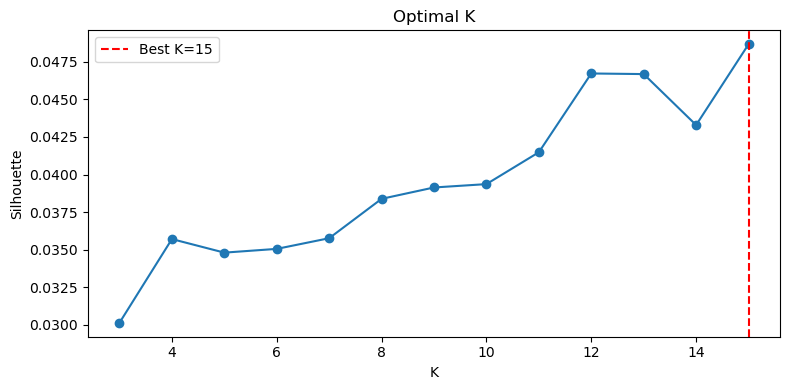

In [6]:
from sklearn.cluster import KMeans as SKKMeans

K_range = range(3, 16)
sil_sample = min(5_000, len(embeddings))
scores = []

for k in K_range:
    km = SKKMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(embeddings)
    s = silhouette_score(embeddings, labels, sample_size=sil_sample, random_state=42)
    scores.append(s)
    print(f'K={k:2d} | silhouette={s:.4f}')

best_k = list(K_range)[int(np.argmax(scores))]
print(f'\nBest K: {best_k} (silhouette={max(scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), scores, 'o-')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K'); plt.ylabel('Silhouette'); plt.title('Optimal K')
plt.legend(); plt.tight_layout()
plt.savefig('/tmp/silhouette_scores.png', dpi=150)
s3.upload_file('/tmp/silhouette_scores.png', bucket, f'figures/silhouette_scores.png')
plt.show()

## 5. Final clustering with SageMaker built-in KMeans

`train_sagemaker_kmeans` launches a managed training job, downloads the cluster centers from the model artifact, and returns the estimator (reusable for batch transform). Training a single `ml.c5.2xlarge` job on 24k × 1024 vectors takes ~4-5 minutes.

In [26]:
%pip install mxnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 153.9 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: graphviz
    Found existing installation: graphviz 0.21
    Uninstalling graphviz-0.21:
      Successfully uninstalled graphviz-0.21
Note: you may need to restart the kernel to use updated packages.


In [19]:
estimator, centers = train_sagemaker_kmeans(
    embeddings=embeddings,
    k=best_k,
    role=role,
    bucket=bucket,
    prefix=f'kmeans',
    instance_type='ml.c5.2xlarge',
)
print(f'Model artifact: {estimator.model_data}')
print(f'Centers shape : {centers.shape}')

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:9                                                                                    │
│                                                                                                  │
│    6 │   prefix=f'kmeans',                                                                       │
│    7 │   instance_type='ml.c5.2xlarge',                                                          │
│    8 )                                                                                           │
│ ❱  9 print(f'Model artifact: {estimator.model_data}')                                            │
│   10 print(f'Centers shape : {centers.shape}')                                                   │
│   11                                                                                             │
╰──────────────────────────────────────────────────────────────────────────────────────────────────╯
AttributeError: 'dict' object has no attribute 'model_data'

In [21]:
desc, centers = estimator, centers
model_uri = desc['ModelArtifacts']['S3ModelArtifacts']
print(f'Training job : {desc["TrainingJobName"]}')
print(f'Model artifact: {model_uri}')
print(f'Centers shape : {centers.shape if centers.size else "(not extracted — use assign_clusters_via_endpoint)"}')


Training job : hey-kmeans-8cd0322b-1777178338
Model artifact: s3://testing-s3-for-api-integration/output/hey-kmeans-8cd0322b-1777178338/output/model.tar.gz
Centers shape : (not extracted — use assign_clusters_via_endpoint)


Assign each conversation to its nearest centroid via a SageMaker batch transform job. This keeps the notebook kernel small — all the math runs on the transform instance.

In [23]:


cluster_labels, distances = assign_clusters_via_endpoint(
    model_uri=model_uri,
    embeddings=embeddings,
    role=role,
    region=region,
    instance_type='ml.m5.large',
)
conv_docs['cluster'] = cluster_labels
conv_docs['dist_to_centroid'] = distances
print(conv_docs['cluster'].value_counts().sort_index())


KMeans predict:   0%|          | 0/49 [00:00<?, ?it/s]

cluster
0      613
1     2175
2     4408
3     1190
4     1091
5     2143
6     5661
7      699
8      662
9      649
10     407
11    1762
12     382
13    1390
14     887
Name: count, dtype: int64


## 6. Semantic labels with Claude

In [25]:


# Re-run cluster assignment via a transient KMeans endpoint.
# This takes ~3-5 min (endpoint cold start dominates) and auto-cleans up.
model_uri = desc['ModelArtifacts']['S3ModelArtifacts']

cluster_labels, distances = assign_clusters_via_endpoint(
    model_uri=model_uri,
    embeddings=embeddings,
    role=role,
    region=region,
    instance_type='ml.m5.large',
)
conv_docs['cluster']          = cluster_labels
conv_docs['dist_to_centroid'] = distances

# Pick the n conversations closest to their centroid per cluster.
# We already have per-point distance, so no centers matrix is needed.
def _pick_samples(conv_docs, n=8):
    out = {}
    for c in sorted(conv_docs['cluster'].unique()):
        subset = conv_docs[conv_docs['cluster'] == c]
        out[int(c)] = subset.nsmallest(n, 'dist_to_centroid')['texto_completo'].tolist()
    return out

samples   = _pick_samples(conv_docs, n=8)



KMeans predict:   0%|          | 0/49 [00:00<?, ?it/s]

Claude labels:   0%|          | 0/15 [00:00<?, ?it/s]

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:25                                                                                   │
│                                                                                                  │
│   22 │   return out                                                                              │
│   23                                                                                             │
│   24 samples   = _pick_samples(conv_docs, n=8)                                                   │
│ ❱ 25 labels_df = label_clusters(samples, clients=bedrock, max_workers=4)                         │
│   26 labels_df                                                                                   │
│   27                                                                                             │
│                                                                                                  │
│ in label_clusters:252                                                                            │
│                                                                                                  │
│   249 │   │   │   for cid, samples in samples_per_cluster.items()                                │
│   250 │   │   ]                                                                                  │
│   251 │   │   for fut in tqdm(as_completed(futures), total=len(futures), desc="Claude labels")   │
│ ❱ 252 │   │   │   rows.append(fut.result())                                                      │
│   253 │   return pd.DataFrame(rows).sort_values("cluster").reset_index(drop=True)                │
│   254                                                                                            │
│   255                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.11/concurrent/futures/_base.py:449 in result                              │
│                                                                                                  │
│   446 │   │   │   │   if self._state in [CANCELLED, CANCELLED_AND_NOTIFIED]:                     │
│   447 │   │   │   │   │   raise CancelledError()                                                 │
│   448 │   │   │   │   elif self._state == FINISHED:                                              │
│ ❱ 449 │   │   │   │   │   return self.__get_result()                                             │
│   450 │   │   │   │                                                                              │
│   451 │   │   │   │   self._condition.wait(timeout)                                              │
│   452                                                                                            │
│                                                                                                  │
│ /opt/conda/lib/python3.11/concurrent/futures/_base.py:401 in __get_result                        │
│                                                                                                  │
│   398 │   def __get_result(self):                                                                │
│   399 │   │   if self._exception:                                                                │
│   400 │   │   │   try:                                                                           │
│ ❱ 401 │   │   │   │   raise self._exception                                                      │
│   402 │   │   │   finally:                                                                       │
│   403 │   │   │   │   # Break a reference cycle with the exception in self._exception            │
│   404 │   │   │   │   self = None                                                                │
│                                                            

In [29]:
bedrock = BedrockClients.build(region=region)
labels_df = label_clusters(samples, clients=bedrock, max_workers=4)
labels_df

Claude labels:   0%|          | 0/15 [00:00<?, ?it/s]

,label,intent,keywords,cluster
0,Solicitar número de atención al cliente,El cliente busca obtener el número telefónico ...,"[número, atención, cliente, contacto, teléfono]",0
1,Aclaración de cargos no reconocidos,El cliente reporta cargos no autorizados en su...,"[cargo no reconocido, aclaración, tarjeta de c...",1
2,Reposición y renovación de tarjeta física,"El cliente solicita ayuda para reemplazar, ren...","[tarjeta física, reposición, vencimiento, bloq...",2
3,Cotización de crédito automotriz,Solicitar cotización y simular opciones de fin...,"[crédito auto, cotización, monto, plazo meses,...",3
4,Información sobre Hey Banco,"El cliente busca conocer qué es Hey Banco, sus...","[Hey Banco, número de contacto, servicios, tra...",4
5,Créditos personales y diferimientos,"Consultas sobre solicitud, aprobación, plazos ...","[crédito personal, diferimiento, plazos, mensu...",5
6,Problemas técnicos y operacionales en transacc...,Usuarios reportan errores al realizar transacc...,"[error técnico, transacciones bloqueadas, apar...",6
7,Cancelación de tarjeta de crédito,El cliente solicita cancelar su tarjeta de cré...,"[cancelar, tarjeta de crédito, cierre de cuent...",7
8,Token incorrecto o inválido,El cliente reporta que recibe un mensaje de er...,"[token, incorrecto, error, validación, autenti...",8
9,Consulta sobre cambio de CLABE interbancaria,El cliente necesita información sobre su CLABE...,"[CLABE, cambio de cuenta, clave interbancaria,...",9


In [30]:
cluster_label_map = dict(zip(labels_df['cluster'], labels_df['label']))
conv_docs['cluster_label'] = conv_docs['cluster'].map(cluster_label_map)

print('CLUSTER SUMMARY')
print('=' * 80)
for _, row in labels_df.iterrows():
    c = int(row['cluster'])
    n = int((conv_docs['cluster'] == c).sum())
    pct = n / len(conv_docs) * 100
    print(f"Cluster {c}: {row['label']} — {n} convs ({pct:.1f}%)")
    print(f"   intent  : {row['intent']}")
    print(f"   keywords: {', '.join(row.get('keywords') or [])}\n")

CLUSTER SUMMARY
Cluster 0: Solicitar número de atención al cliente — 613 convs (2.5%)
   intent  : El cliente busca obtener el número telefónico de atención al cliente
   keywords: número, atención, cliente, contacto, teléfono

Cluster 1: Aclaración de cargos no reconocidos — 2175 convs (9.0%)
   intent  : El cliente reporta cargos no autorizados en su cuenta y solicita información sobre cómo hacer una aclaración o seguimiento del proceso
   keywords: cargo no reconocido, aclaración, tarjeta de crédito, reembolso, transacción no autorizada

Cluster 2: Reposición y renovación de tarjeta física — 4408 convs (18.3%)
   intent  : El cliente solicita ayuda para reemplazar, renovar o reponer su tarjeta física por vencimiento, pérdida o bloqueo
   keywords: tarjeta física, reposición, vencimiento, bloqueo, renovación

Cluster 3: Cotización de crédito automotriz — 1190 convs (4.9%)
   intent  : Solicitar cotización y simular opciones de financiamiento para compra de vehículo
   keywords: crédi

## 7. 2-D visualization

In [33]:
print(centers)

[]


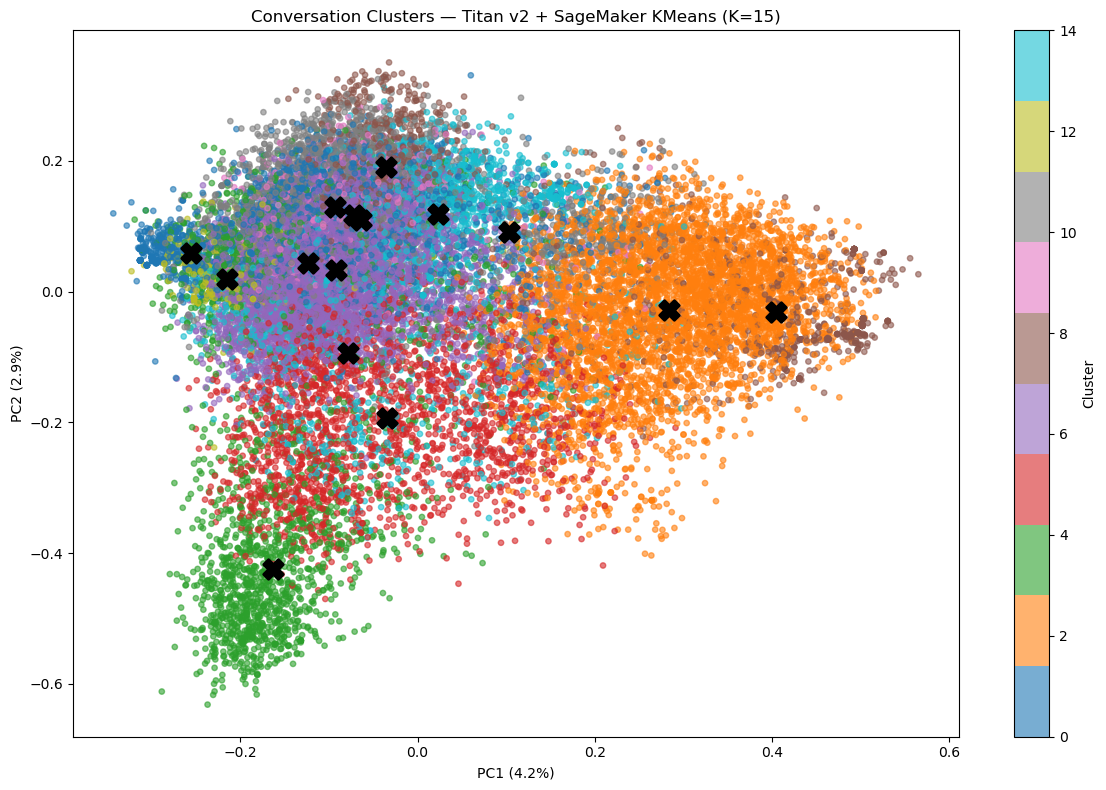

In [34]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Per-cluster mean embedding — same shape as true centroids, visually equivalent for a 2-D overview.
unique_clusters = np.sort(conv_docs['cluster'].unique())
centers_pseudo = np.stack([
    embeddings[conv_docs['cluster'].values == c].mean(axis=0)
    for c in unique_clusters
])

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)
centroids_2d = pca.transform(centers_pseudo)

plt.figure(figsize=(12, 8))
sc = plt.scatter(coords[:, 0], coords[:, 1], c=conv_docs['cluster'],
                 cmap='tab10', alpha=0.6, s=15)
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', marker='X',
            s=200, linewidths=2)
plt.colorbar(sc, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title(f'Conversation Clusters — Titan v2 + SageMaker KMeans (K={best_k})')
plt.tight_layout()
plt.savefig('/tmp/conversation_clusters.png', dpi=150)
s3.upload_file('/tmp/conversation_clusters.png', bucket, f'figures/conversation_clusters.png')
plt.show()


## 8. Roll up to user level

In [35]:
user_segments = (
    conv_docs.groupby('user_id')
    .agg(
        cluster_dominante=('cluster', lambda x: x.mode().iloc[0]),
        cluster_label_dominante=('cluster_label', lambda x: x.mode().iloc[0]),
        num_clusters_distintos=('cluster', 'nunique'),
    )
    .reset_index()
)

cluster_dummies = pd.get_dummies(
    conv_docs.groupby('user_id')['cluster'].apply(list).explode(),
    prefix='seg',
)
cluster_user = cluster_dummies.groupby(level=0).sum().clip(upper=1)
cluster_user.index.name = 'user_id'

user_segments = user_segments.merge(cluster_user, on='user_id', how='left')
print(user_segments.shape)
user_segments.head()

(15025, 19)


,user_id,cluster_dominante,cluster_label_dominante,num_clusters_distintos,seg_0,seg_1,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,seg_12,seg_13,seg_14
0,USR-00001,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,USR-00002,3,Cotización de crédito automotriz,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,USR-00003,6,Problemas técnicos y operacionales en transacc...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,USR-00004,7,Cancelación de tarjeta de crédito,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,USR-00005,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [38]:
user_segments

,user_id,cluster_dominante,cluster_label_dominante,num_clusters_distintos,seg_0,seg_1,seg_2,seg_3,seg_4,seg_5,seg_6,seg_7,seg_8,seg_9,seg_10,seg_11,seg_12,seg_13,seg_14
0,USR-00001,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1,USR-00002,3,Cotización de crédito automotriz,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2,USR-00003,6,Problemas técnicos y operacionales en transacc...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,USR-00004,7,Cancelación de tarjeta de crédito,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,USR-00005,5,Créditos personales y diferimientos,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15020,USR-15021,12,Consulta y gestión de estado de cuenta,2,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0
15021,USR-15022,6,Problemas técnicos y operacionales en transacc...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
15022,USR-15023,6,Problemas técnicos y operacionales en transacc...,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
15023,USR-15024,3,Cotización de crédito automotriz,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0


## 9. Persist outputs to S3

In [37]:
def _put_csv(df: pd.DataFrame, key: str) -> str:
    buf = io.StringIO()
    df.to_csv(buf, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buf.getvalue())
    uri = f's3://{bucket}/{key}'
    print(f'wrote {uri}')
    return uri

_put_csv(conv_docs,     f'outputs/conversations_clustered.csv')
_put_csv(user_segments, f'outputs/user_chat_segments.csv')
_put_csv(labels_df,     f'outputs/cluster_labels.csv')

# Centers for downstream reuse
centers_buf = io.BytesIO()
np.save(centers_buf, centers)
s3.put_object(Bucket=bucket, Key=f'outputs/cluster_centers.npy', Body=centers_buf.getvalue())
print(f'wrote s3://{bucket}/outputs/cluster_centers.npy')

wrote s3://testing-s3-for-api-integration/outputs/conversations_clustered.csv
wrote s3://testing-s3-for-api-integration/outputs/user_chat_segments.csv
wrote s3://testing-s3-for-api-integration/outputs/cluster_labels.csv
wrote s3://testing-s3-for-api-integration/outputs/cluster_centers.npy


## 10. Cleanup

We used a batch transform (no persistent endpoint), so there's nothing to delete for inference. The training job and its artifact stay in S3 for auditing. Delete them manually if you want:

```python
# s3.delete_object(Bucket=bucket, Key=<estimator.model_data path>)
```